In [32]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [33]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def softmax(z):
    z = z - z.max(dim=1, keepdim=True)[0]
    return torch.exp(z) / torch.exp(z).sum(dim=1, keepdim=True)

In [34]:
def bce(p, y):
    return -(y * torch.log(p) + (1 - y) * torch.log(1 - p)).mean()

def cce(p, y):
    return -(y * torch.log(p)).sum(dim=1).mean()

def mse(y_hat, y):
    return ((y_hat - y) ** 2).mean()

def mae(y_hat, y):
    return torch.abs(y_hat - y).mean()

In [35]:
def forward(X, W1, b1, W2, b2, out="sigmoid"):
    h = sigmoid(X @ W1 + b1)
    z = h @ W2 + b2
    if out == "sigmoid":
        return sigmoid(z)
    if out == "softmax":
        return softmax(z)
    return z

In [36]:
def cf_mat(X, y, W1, b1, W2, b2):
    with torch.no_grad():
        probs = forward(X, W1, b1, W2, b2, out="sigmoid")
        preds = (probs > 0.5).int().view(-1).numpy()

    y_true = y.view(-1).numpy().astype(int)

    # confusion matrix values
    TP = np.sum((preds == 1) & (y_true == 1))
    TN = np.sum((preds == 0) & (y_true == 0))
    FP = np.sum((preds == 1) & (y_true == 0))
    FN = np.sum((preds == 0) & (y_true == 1))

    cm = np.array([[TN, FP],
                [FN, TP]])

    print("Confusion Matrix:")
    print(cm)

In [37]:
df = pd.read_csv("pumpkin_seeds.csv", encoding="latin1")
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values
classes = np.unique(y_raw)
y = (y_raw == classes[1]).astype(np.float32).reshape(-1, 1)

X = torch.tensor(StandardScaler().fit_transform(X), dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

D, H = X.shape[1], 16
W1 = torch.randn(D, H) * 0.1
b1 = torch.zeros(H)
W2 = torch.randn(H, 1) * 0.1
b2 = torch.zeros(1)

p = forward(X, W1, b1, W2, b2, out="sigmoid")
print("Pumpkin BCE:", bce(p, y).item())

cf_mat(X, y, W1, b1, W2, b2)

Pumpkin BCE: 0.7016022205352783
Confusion Matrix:
[[   0 1300]
 [   0 1200]]


In [38]:
def confusion_matrix_multiclass(X, y_onehot, forward_fn, params):
    W1, b1, W2, b2 = params

    with torch.no_grad():
        probs = forward_fn(X, W1, b1, W2, b2, out="softmax")
        y_pred = torch.argmax(probs, dim=1).cpu().numpy()

    y_true = torch.argmax(y_onehot, dim=1).cpu().numpy()
    C = y_onehot.shape[1]

    cm = np.zeros((C, C), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    return cm

In [39]:
iris = load_iris()
X = iris.data
y = iris.target
C = len(np.unique(y))
y_oh = np.eye(C)[y]

X = torch.tensor(StandardScaler().fit_transform(X), dtype=torch.float32)
y_oh = torch.tensor(y_oh, dtype=torch.float32)

D, H = X.shape[1], 16
W1 = torch.randn(D, H) * 0.1
b1 = torch.zeros(H)
W2 = torch.randn(H, C) * 0.1
b2 = torch.zeros(C)

p = forward(X, W1, b1, W2, b2, out="softmax")
print("Iris CCE:", cce(p, y_oh).item())

cm = confusion_matrix_multiclass(
    X, y_oh,
    forward_fn=forward,
    params=(W1, b1, W2, b2)
)

print("Confusion Matrix (Iris):")
print(cm)


Iris CCE: 1.1079357862472534
Confusion Matrix (Iris):
[[50  0  0]
 [50  0  0]
 [50  0  0]]


In [40]:
house = fetch_california_housing()
X = house.data
y = house.target.reshape(-1, 1)

X_train, _, y_train, _ = train_test_split(X, y, train_size=2000)

X = torch.tensor(StandardScaler().fit_transform(X_train), dtype=torch.float32)
y = torch.tensor(y_train, dtype=torch.float32)

D, H = X.shape[1], 32
W1 = torch.randn(D, H) * 0.1
b1 = torch.zeros(H)
W2 = torch.randn(H, 1) * 0.1
b2 = torch.zeros(1)

y_hat = forward(X, W1, b1, W2, b2, out="linear")
print("House MSE:", mse(y_hat, y).item())
print("House MAE:", mae(y_hat, y).item())

House MSE: 8.804619789123535
House MAE: 2.7262473106384277


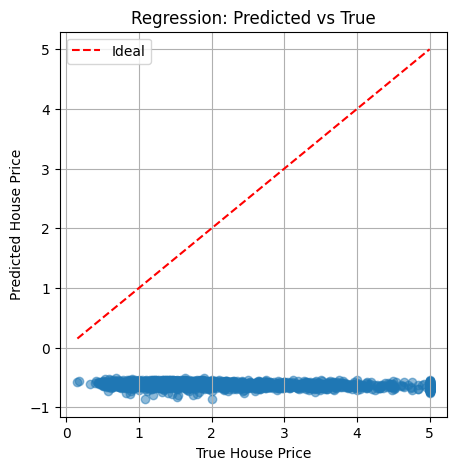

In [41]:
with torch.no_grad():
    y_pred = y_hat.view(-1).numpy()
    y_true = y.view(-1).numpy()

plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', label="Ideal")

plt.xlabel("True House Price")
plt.ylabel("Predicted House Price")
plt.title("Regression: Predicted vs True")
plt.legend()
plt.grid(True)
plt.show()
